In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the file directly from your session storage
df = pd.read_csv('/content/retail_sales_timeseries.csv')
df.head()

,Index,Date,Year,Month,Sales_USD,MoM_Change_Pct,Season,Trend
0,1,Jan 2023,2023,1,42300,NaN,Winter,Early growth
1,2,Feb 2023,2023,2,38900,-8.0,Winter,Early growth
2,3,Mar 2023,2023,3,45700,17.5,Spring,Early growth
3,4,Apr 2023,2023,4,49200,7.7,Spring,Early growth
4,5,May 2023,2023,5,53600,8.9,Spring,Early growth


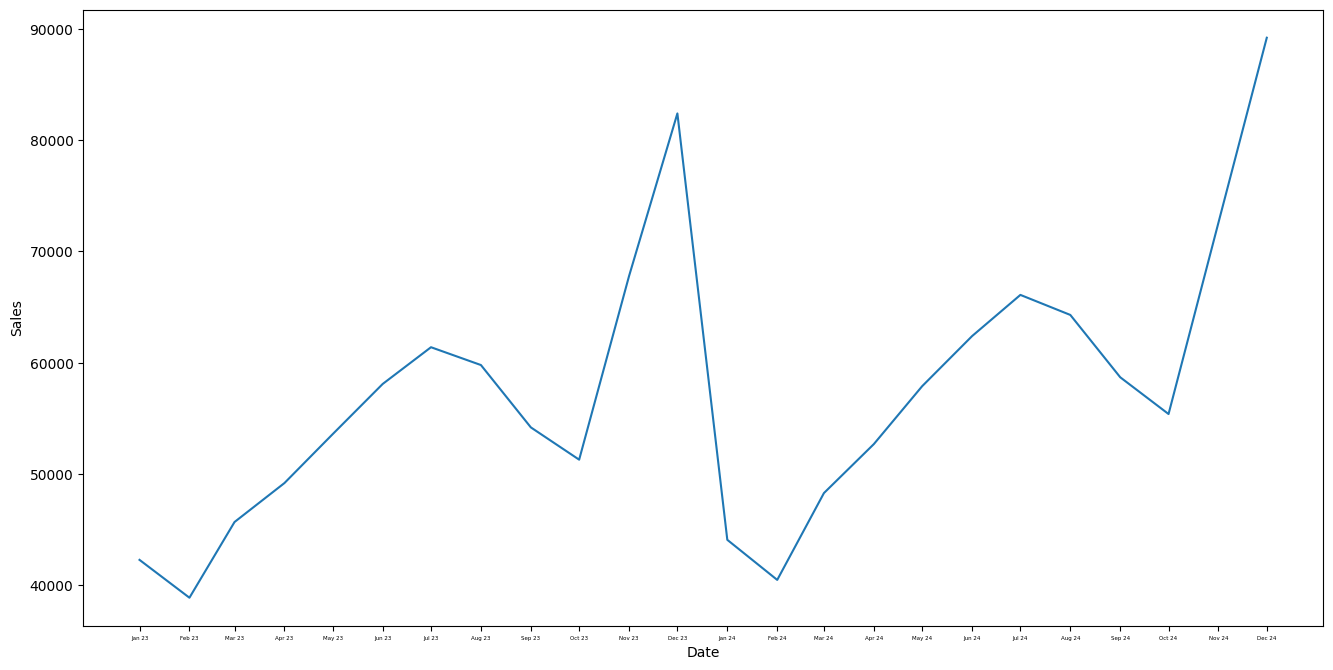

In [ ]:
import matplotlib.pyplot as plt
df['Date']=pd.to_datetime(df['Date'], format ='%b %Y')
df=df.sort_values('Date').reset_index(drop=True)

fig,ax=plt.subplots(figsize=(16,8))
ax.plot(df['Date'],df['Sales_USD'])
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_xticks(df['Date'])
ax.set_xticklabels(df['Date'].dt.strftime('%b %y'),fontsize=4)
ax.marker="x"

In [ ]:
print(f"The best sales was in the the month: {df.loc[df['Sales_USD'].idxmax()]['Date'].strftime('%b %Y')}")

The best sales was in the the month: Dec 2024


In [ ]:
print(f"The worst sales was in the the month: {df.loc[df['Sales_USD'].idxmin()]['Date'].strftime('%b %Y')}")

The worst sales was in the the month: Feb 2023


DAY 2


Test dataset and Train dataset make the entire dataset and this partitioning is completely logical and not physical.

Techniques to partition-:
1. Random
2. Specific

Random selection would involve usage of code to pull out random rows from the dataset for partitioning

In specific selection, I as the programmer would have to decide how to segregate.

Training time depends on-:
1. Model Complexity
2. Dataset Size
3. Computing power of the machine (CPU and GPU)

We also need to maintain a training log to understand if the model is being trained well.

Test data and Train data should never have anything in common. Otherwise the situation of data leakage arises.

Currently we are dealing with simple data so we would go with ML models. Later when the model becomes complex we can use deep learning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the file directly from your session storage
df = pd.read_csv('/content/retail_sales_timeseries.csv')
df['Date']=pd.to_datetime(df['Date'], format ='%b %Y')
df.head()

,Index,Date,Year,Month,Sales_USD,MoM_Change_Pct,Season,Trend
0,1,2023-01-01,2023,1,42300,NaN,Winter,Early growth
1,2,2023-02-01,2023,2,38900,-8.0,Winter,Early growth
2,3,2023-03-01,2023,3,45700,17.5,Spring,Early growth
3,4,2023-04-01,2023,4,49200,7.7,Spring,Early growth
4,5,2023-05-01,2023,5,53600,8.9,Spring,Early growth


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
train=df[(df['Date']>="2023-01-01")&
         (df['Date']<="2024-08-31")]
test=df[(df['Date']>="2024-09-01") &
        (df['Date']<="2024-12-31")]

In [ ]:
model=ExponentialSmoothing(
    train["Sales_USD"],
    trend="add",
    seasonal="add",
    seasonal_periods=10
).fit()

seasonal_period is something set by the developer to explain when the cycle repeats.

Atleast two seasonality periods are required.

fit() is used for caling the training

In [ ]:
predicted_sales=model.forecast(steps=len(test))
mae=mean_absolute_error(test['Sales_USD'],predicted_sales)
mse=mean_squared_error(test['Sales_USD'],predicted_sales)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

Mean Absolute Error: 27130.00710151699
Mean Squared Error: 862324594.1056974


Here the MAE and MSE are very large because the available dataset is very small.Hence we aren't able to get exact results.

In [ ]:
results=pd.DataFrame({
    "Date":test["Date"],
    "Predicted_Sales":predicted_sales,
    "Actual_Sales":test["Sales_USD"],
    "Difference":predicted_sales-test["Sales_USD"]
})
results

,Date,Predicted_Sales,Actual_Sales,Difference
20,2024-09-01,70977.760265,58700,12277.760265
21,2024-10-01,85432.254901,55400,30032.254901
22,2024-11-01,49612.693667,72600,-22987.306333
23,2024-12-01,45977.293092,89200,-43222.706908


In [ ]:
predicted=model.forecast(1).iloc[-1]
print(predicted)

70977.76026462427


In [ ]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

In [ ]:
model_1=ETSModel(
    train["Sales_USD"],
    trend="add",
    seasonal="add",
    seasonal_periods=10
).fit()


In [ ]:
predicted_sales=model_1.forecast(steps=len(test))
mae=mean_absolute_error(test['Sales_USD'],predicted_sales)
mse=mean_squared_error(test['Sales_USD'],predicted_sales)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

Mean Absolute Error: 18719.5127860768
Mean Squared Error: 579110786.2135837


In [ ]:
results=pd.DataFrame({
    "Date":test["Date"],
    "Predicted_Sales":predicted_sales,
    "Actual_Sales":test["Sales_USD"],
    "Difference":predicted_sales-test["Sales_USD"]
})
results

,Date,Predicted_Sales,Actual_Sales,Difference
20,2024-09-01,56726.713489,58700,-1973.286511
21,2024-10-01,63245.816826,55400,7845.816826
22,2024-11-01,48275.984604,72600,-24324.015396
23,2024-12-01,48465.067589,89200,-40734.932411


DAY 3

Sequence Modelling
Sequence refers to time series. When we make some analysis on it then it can be referred to as Sequence Modelling.

Most of the algorithms that we have are pre definedand we don't change much stuff.

Also in this project we are dealing with multivariate data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df_day3=pd.read_csv('/content/timeseries_dataset.csv')

In [ ]:
from statsmodels.tsa.forecasting.theta import ThetaModel
model=ThetaModel(train["Sales_USD"], period=10).fit() # Added period=10 based on ExponentialSmoothing model
prediction=model.forecast(4)
print(prediction)

20    64268.566932
21    64652.852646
22    65037.138360
23    65421.424075
Name: forecast, dtype: float64


In [ ]:
from statsmodels.tsa.ar_model import AutoReg
model=AutoReg(train["Sales_USD"], lags=5).fit()
prediction=model.forecast(steps=4)
print(prediction)

20    54686.543692
21    51015.579577
22    54083.935766
23    57088.113168
dtype: float64


In [ ]:
from statsmodels.tsa.holtwinters import Holt
model=Holt(train["Sales_USD"]).fit()
prediction=model.forecast(steps=4)
print(prediction)


20    63784.692062
21    63269.384104
22    62754.076146
23    62238.768188
dtype: float64


While participating in Hackathons and stuff we can make use of pre trained models because they are already trained on lots of data. So it is more generic.

Most of the times researchers use pre trained models. However one must know how to design these models.

Under arima we have something called order(p,q,r)
p-: How many past values will be used to predict future
q-: It is used to determine the trend
r-: It is used to study from the last two mistakes.(Back tracking)

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
model=SimpleExpSmoothing(train["Sales_USD"]).fit()
prediction=model.forecast(steps=4)
print(prediction)


20    63551.492407
21    63551.492407
22    63551.492407
23    63551.492407
dtype: float64


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train["Sales_USD"], order=(5,1,0)).fit()
prediction=model.forecast(steps=4)
print(prediction)

20    64449.087841
21    65374.011638
22    65755.611533
23    65754.129102
Name: predicted_mean, dtype: float64


ARIMA,ARMA and SARIMA are three very important models in time series analysis.

In ML we first of all need to preprocess the data, however in DL we can even pass the dataset directly.
In DL we need a very large dataset.
Whether or not to use DL depends on the programmer. We can always use the method of trial and error

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(train["Sales_USD"], order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
prediction=model.forecast(steps=4)
print(prediction)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


20    58225.663372
21    55152.341756
22    73545.550034
23    89934.138850
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Dealing with the new dataset

In [ ]:
print(df_day3['date'][0])
print(df_day3['date'].iloc[-1])

01-01-21
31-12-27


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(df_day3["target"], order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
prediction=model.forecast(steps=4)
print(prediction)


2556    671.037001
2557    670.462306
2558    671.478388
2559    670.813426
Name: predicted_mean, dtype: float64


In [ ]:
df_day3.set_index("date",inplace=True)

In [ ]:
df_day3.index = pd.to_datetime(df_day3.index, format='%d-%m-%y')
df_day3["year"]=df_day3.index.year
df_day3["month"]=df_day3.index.month
df_day3["day"]=df_day3.index.day
df_day3["dayofweek"]=df_day3.index.dayofweek

In [ ]:
train_d3=df_day3[(df_day3.index>="01-01-2021")&
         (df_day3.index<="30-11-2027")]
test_d3=df_day3[(df_day3.index>="01-12-2027") &
        (df_day3.index<="31-12-2027")]

In [ ]:
features=[
    "year",
    "month",
    "day",
    "dayofweek",
    "feature1",
    "feature2"
]
X_train=train_d3[features]
y_train=train_d3["target"]
X_test=test_d3[features]
y_test=test_d3["target"]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, rf_predictions)
mse_rf = mean_squared_error(y_test, rf_predictions)

print(f"Random Forest - Mean Absolute Error: {mae_rf}")
print(f"Random Forest - Mean Squared Error: {mse_rf}")

Random Forest - Mean Absolute Error: 2.759432485875771
Random Forest - Mean Squared Error: 21.548671405339032
